# SaaS UX & Churn Analysis
This project analyzes user interaction logs (digital footprints) and customer support feedback (psychometrics) to predict subscription churn for a SaaS platform.

## Phase 1: Data Ingestion & Exploration
In this section, we load the relational datasets from the RavenStack ecosystem to understand customer profiles and daily application usage.


In [2]:
import os 
import pandas as pd


In [3]:
# Cell 2: Define the relative path to the data folder
data_directory = "../data/"

# List all files inside the data directory to ensure they are there
files_in_data = os.listdir(data_directory)
print(files_in_data)

['.ipynb_checkpoints', 'processed_churn_data.csv', 'ravenstack_accounts.csv', 'ravenstack_churn_events.csv', 'ravenstack_feature_usage.csv', 'ravenstack_subscriptions.csv', 'ravenstack_support_tickets.csv']


In [4]:
# Load the main accounts dataset
accounts_df = pd.read_csv(os.path.join(data_directory,'ravenstack_accounts.csv'))
accounts_df.head()

,account_id,account_name,industry,country,signup_date,referral_source,plan_tier,seats,is_trial,churn_flag
0,A-2e4581,Company_0,EdTech,US,2024-10-16,partner,Basic,9,False,False
1,A-43a9e3,Company_1,FinTech,IN,2023-08-17,other,Basic,18,False,True
2,A-0a282f,Company_2,DevTools,US,2024-08-27,organic,Basic,1,False,False
3,A-1f0ac7,Company_3,HealthTech,UK,2023-08-27,other,Basic,24,True,False
4,A-ce550d,Company_4,HealthTech,US,2024-10-27,event,Enterprise,35,False,True


In [5]:
# load the digital footprint dataset
usage_df = pd.read_csv(os.path.join(data_directory,'ravenstack_feature_usage.csv'))
usage_df.head()


,usage_id,subscription_id,usage_date,feature_name,usage_count,usage_duration_secs,error_count,is_beta_feature
0,U-1c6c24,S-0fcf7d,2023-07-27,feature_20,9,5004,0,False
1,U-f07cb8,S-c25263,2023-08-07,feature_5,9,369,0,False
2,U-096807,S-f29e7f,2023-12-07,feature_3,9,1458,0,False
3,U-6b1580,S-be655e,2024-07-28,feature_40,5,2085,0,False
4,U-720a29,S-f9b1d0,2024-12-02,feature_12,12,900,0,False


In [6]:
# Customer support and satisfaction dataset
support_df = pd.read_csv(os.path.join(data_directory,'ravenstack_support_tickets.csv'))
support_df.head()

,ticket_id,account_id,submitted_at,closed_at,resolution_time_hours,priority,first_response_time_minutes,satisfaction_score,escalation_flag
0,T-0024de,A-712f1c,2023-07-27,2023-07-28 03:00:00,27.0,high,74,NaN,False
1,T-4d04b9,A-e43bf7,2024-07-08,2024-07-09 03:00:00,27.0,urgent,144,NaN,False
2,T-d5e12f,A-0f3e88,2024-10-17,2024-10-17 19:00:00,19.0,urgent,93,4.0,False
3,T-dfce9a,A-4c56c9,2024-09-08,2024-09-09 23:00:00,47.0,medium,126,5.0,False
4,T-c59f77,A-6f8ad2,2024-11-30,2024-12-01 02:00:00,26.0,medium,8,NaN,False


In [7]:
#Now the churn dataset
churn_df = pd.read_csv(os.path.join(data_directory,'ravenstack_churn_events.csv'))
churn_df.head()

,churn_event_id,account_id,churn_date,reason_code,refund_amount_usd,preceding_upgrade_flag,preceding_downgrade_flag,is_reactivation,feedback_text
0,C-816288,A-c37cab,2024-10-27,pricing,4.03,False,False,False,switched to competitor
1,C-5a81e7,A-37f969,2024-06-25,support,96.45,True,False,False,NaN
2,C-a174be,A-b07346,2024-11-12,budget,0.00,False,False,False,missing features
3,C-accb39,A-1e50e0,2023-11-01,budget,54.94,False,False,False,switched to competitor
4,C-92f889,A-956988,2024-12-30,unknown,0.00,False,True,True,too expensive


In [8]:
# just checking that a same client can use the service more than once:
total_rows = len(usage_df)
unique_subscriptions = usage_df['subscription_id'].nunique()

print(f"Total rows in usage dataset: {total_rows}")
print(f"Unique subscription IDs: {unique_subscriptions}")

Total rows in usage dataset: 25000
Unique subscription IDs: 4967


In [9]:
# agregating daily feature usage by subscription
aggregate_usage_df = usage_df.groupby('subscription_id').agg(total_clicks=('usage_count','sum'),
                                                            total_duration_seconds = ('usage_duration_secs','sum'),
                                                            total_errors = ('error_count','sum')).reset_index()
aggregate_usage_df.head()

,subscription_id,total_clicks,total_duration_seconds,total_errors
0,S-001561,48,21604,3
1,S-0027d3,44,20848,0
2,S-003647,71,13018,3
3,S-003fc0,43,11933,1
4,S-004d19,18,5616,0


In [10]:
# connecting subscriptions to accounts
subscriptions_df = pd.read_csv(os.path.join(data_directory,"ravenstack_subscriptions.csv"))
subscriptions_df.head()

,subscription_id,account_id,start_date,end_date,plan_tier,seats,mrr_amount,arr_amount,is_trial,upgrade_flag,downgrade_flag,churn_flag,billing_frequency,auto_renew_flag
0,S-8cec59,A-3c1a3f,2023-12-23,2024-04-12,Enterprise,14,2786,33432,False,False,False,True,monthly,True
1,S-0f6f44,A-9b9fe9,2024-06-11,NaN,Pro,17,833,9996,False,False,False,False,monthly,True
2,S-51c0d1,A-659280,2024-11-25,NaN,Enterprise,62,0,0,True,True,False,False,annual,False
3,S-f81687,A-e7a1e2,2024-11-23,2024-12-13,Enterprise,5,995,11940,False,False,False,True,monthly,True
4,S-cff5a2,A-ba6516,2024-01-10,NaN,Enterprise,27,5373,64476,False,False,False,False,monthly,True


In [11]:
# merge/join the subscriptions and the aggregated usage datasets.
subscriptions_usage_df = pd.merge(
    subscriptions_df,
    aggregate_usage_df,
    on = 'subscription_id',
    how = 'left'
)
subscriptions_usage_df.head()

,subscription_id,account_id,start_date,end_date,plan_tier,seats,mrr_amount,arr_amount,is_trial,upgrade_flag,downgrade_flag,churn_flag,billing_frequency,auto_renew_flag,total_clicks,total_duration_seconds,total_errors
0,S-8cec59,A-3c1a3f,2023-12-23,2024-04-12,Enterprise,14,2786,33432,False,False,False,True,monthly,True,63.0,26418.0,2.0
1,S-0f6f44,A-9b9fe9,2024-06-11,NaN,Pro,17,833,9996,False,False,False,False,monthly,True,36.0,6819.0,6.0
2,S-51c0d1,A-659280,2024-11-25,NaN,Enterprise,62,0,0,True,True,False,False,annual,False,25.0,13877.0,2.0
3,S-f81687,A-e7a1e2,2024-11-23,2024-12-13,Enterprise,5,995,11940,False,False,False,True,monthly,True,65.0,22943.0,5.0
4,S-cff5a2,A-ba6516,2024-01-10,NaN,Enterprise,27,5373,64476,False,False,False,False,monthly,True,NaN,NaN,NaN


In [12]:
# merge the accounts df with the subscriptions_usage
master_df = pd.merge(subscriptions_usage_df,accounts_df,on = 'account_id', how = 'left')
print("Master Dataframe shape = {}".format(master_df.shape))

Master Dataframe shape = (5000, 26)


In [13]:
# Analyze the relationship between plan tiers and financial metrics (optional its just curiosity)
plan_analysis = master_df.groupby('plan_tier_x').agg(
    avg_seats=('seats_x', 'mean'),
    avg_mrr=('mrr_amount', 'mean'),
    total_accounts=('account_id', 'count')
).reset_index()

# Display the financial summary by tier
plan_analysis

,plan_tier_x,avg_seats,avg_mrr,total_accounts
0,Basic,29.570537,474.679775,1602
1,Enterprise,29.369704,4917.713871,1723
2,Pro,30.617313,1256.769552,1675


In [14]:
# Start filtering for NaNs 
#missing values per column
missing_values_summary = master_df.isnull().sum()
#show only the columns with nans
missing_values_summary[missing_values_summary > 0 ]

end_date                  4514
total_clicks                33
total_duration_seconds      33
total_errors                33
dtype: int64

In [15]:
# fill the missing values with zeroes
usage_columns = ['total_clicks','total_duration_seconds','total_errors']
master_df[usage_columns] = master_df[usage_columns].fillna(0)
# check 
master_df[usage_columns].isnull().sum()

total_clicks              0
total_duration_seconds    0
total_errors              0
dtype: int64

In [16]:
# create a psychometric/UX DF for user satisfaction analysis
aggregated_support_df = support_df.groupby('account_id').agg(
    total_tickets = ('ticket_id','count'),
    average_satisfaction = ('satisfaction_score','mean')).reset_index()
#preview
aggregated_support_df.head()

,account_id,total_tickets,average_satisfaction
0,A-00bed1,4,4.0
1,A-00cac8,2,NaN
2,A-0158bb,1,3.0
3,A-016043,3,4.0
4,A-019782,2,3.0


In [17]:
# We are going to use the mean as a metric for filling the NaNs
#instead of assuming it's zero or deleting that client's data
global_satisfaction_mean = aggregated_support_df['average_satisfaction'].mean()
aggregated_support_df['average_satisfaction'] = aggregated_support_df['average_satisfaction'].fillna(global_satisfaction_mean)

#preview
aggregated_support_df.head()


,account_id,total_tickets,average_satisfaction
0,A-00bed1,4,4.000000
1,A-00cac8,2,3.964163
2,A-0158bb,1,3.000000
3,A-016043,3,4.000000
4,A-019782,2,3.000000


In [18]:
# Now let's merge this with our master DF
master_df = pd.merge(master_df,aggregated_support_df, on = "account_id",how = "left")
# Preview the new columns in the master dataset
master_df[['account_id', 'total_tickets', 'average_satisfaction']].head()

,account_id,total_tickets,average_satisfaction
0,A-3c1a3f,4.0,3.500000
1,A-9b9fe9,4.0,4.000000
2,A-659280,4.0,4.333333
3,A-e7a1e2,1.0,4.000000
4,A-ba6516,6.0,4.000000


In [19]:
# Handle missing values for customers with zero support interactions
master_df['total_tickets'] = master_df['total_tickets'].fillna(0)
master_df['average_satisfaction'] = master_df['average_satisfaction'].fillna(global_satisfaction_mean)

# Verify that no missing values remain in these specific columns
master_df[['total_tickets', 'average_satisfaction']].isnull().sum()


total_tickets           0
average_satisfaction    0
dtype: int64

In [20]:
# Finally , merge Churn dataframe with master dataframe
master_df = pd.merge(master_df,churn_df,on='account_id',how = 'left')
# shape of the DF
print(f"Final Master Dataframe shape: {master_df.shape} ")

Final Master Dataframe shape: (7429, 36) 


In [21]:
# Cell : Create a binary target column for classification based on churn events
master_df['has_churned'] = master_df['churn_date'].notnull().astype(int)

# Verify the balance of our target variable (active vs churned rows)
master_df['has_churned'].value_counts()

has_churned
1    5957
0    1472
Name: count, dtype: int64

In [22]:
# Save the processed DataFrame
processed_data_path = os.path.join(data_directory,'processed_churn_data.csv')
master_df.to_csv(processed_data_path, index = "False")
print(f"Dataset successfully saved to : {processed_data_path}")

Dataset successfully saved to : ../data/processed_churn_data.csv


## Phase 2: Exploratory Data Analysis (EDA)
In this section, we investigate the driving factors behind customer churn. We explore the relationship between the system's operational quality (UX footprints) and client sentiment scores (psychometrics).


In [23]:
# libraries for EDA exploratory data analysis:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style = 'whitegrid')

In [24]:
# analyse churn reasons:
churn_reasons_summary = master_df['reason_code'].value_counts()
# Display the ranked list of reasons why customers cancelled
print("Top reasons for subscription cancellation:")
print(churn_reasons_summary)

Top reasons for subscription cancellation:
reason_code
features      1176
budget        1051
support       1023
pricing        908
competitor     900
unknown        899
Name: count, dtype: int64


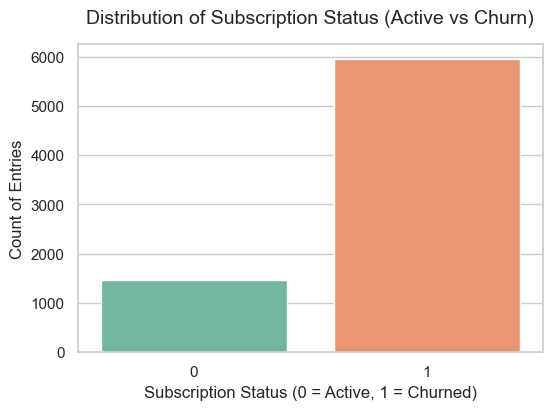

In [25]:
# lets start the graphs with a simple churn vs active graph
plt.figure(figsize=(6,4))
ax = sns.countplot(data=master_df, x = 'has_churned', hue = "has_churned", palette = 'Set2', legend = False)
plt.title('Distribution of Subscription Status (Active vs Churn)', fontsize=14, pad=15)
plt.xlabel('Subscription Status (0 = Active, 1 = Churned)', fontsize=12)
plt.ylabel('Count of Entries', fontsize=12)
plt.show()

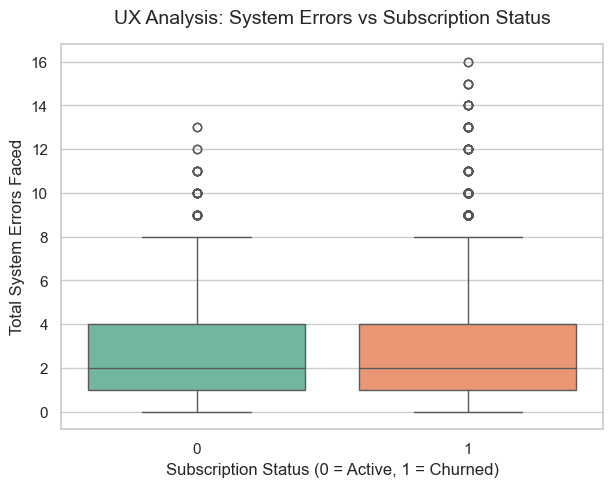

In [26]:
# now we are going to cross the churn data with error data 
plt.figure(figsize = (7,5))
sns.boxplot(data=master_df, x='has_churned', y='total_errors', palette='Set2', hue='has_churned', legend=False)
plt.title('UX Analysis: System Errors vs Subscription Status', fontsize=14, pad=15)
plt.xlabel('Subscription Status (0 = Active, 1 = Churned)', fontsize=12)
plt.ylabel('Total System Errors Faced', fontsize=12)
plt.show()

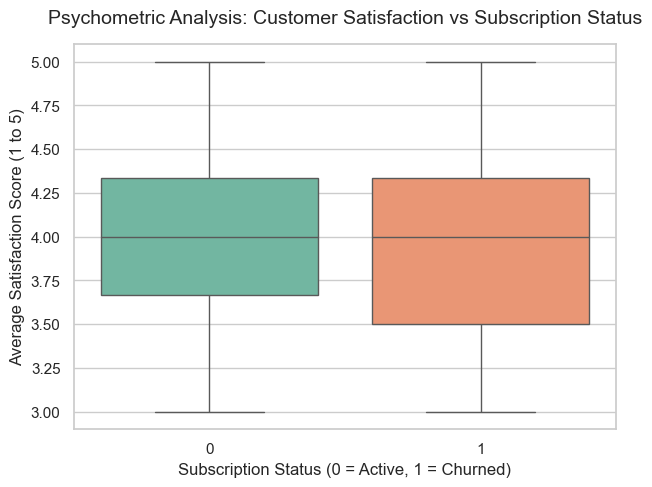

In [27]:
# Now Satisfaction scores vs churn
plt.figure(figsize = (7,5))
sns.boxplot(data = master_df, x = 'has_churned', y = 'average_satisfaction', palette = 'Set2', hue = 'has_churned', legend = False)
# Add presentation titles for psychometric analysis
plt.title('Psychometric Analysis: Customer Satisfaction vs Subscription Status', fontsize=14, pad=15)
plt.xlabel('Subscription Status (0 = Active, 1 = Churned)', fontsize=12)
plt.ylabel('Average Satisfaction Score (1 to 5)', fontsize=12)

plt.show()

In [28]:
# system usage and churn
engagement_summary = master_df.groupby('has_churned')['total_duration_seconds'].mean().reset_index()
# Convert seconds to hours for better business readability
engagement_summary['total_duration_hours'] = engagement_summary['total_duration_seconds'] / 3600
engagement_summary

,has_churned,total_duration_seconds,total_duration_hours
0,0,15069.983016,4.186106
1,1,15268.953332,4.241376


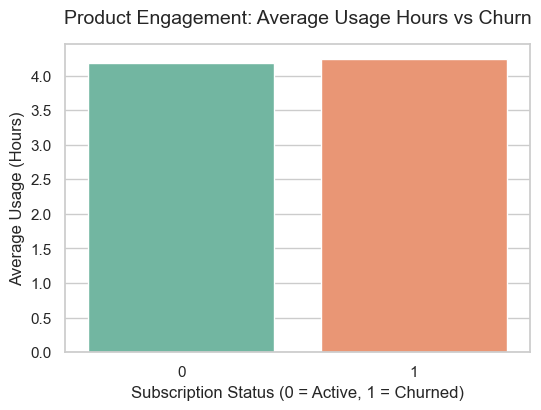

In [29]:
# Plot average usage duration by subscription status
plt.figure(figsize=(6, 4))
sns.barplot(data=engagement_summary, x='has_churned', y='total_duration_hours', palette='Set2', hue='has_churned', legend=False)

plt.title('Product Engagement: Average Usage Hours vs Churn', fontsize=14, pad=15)
plt.xlabel('Subscription Status (0 = Active, 1 = Churned)', fontsize=12)
plt.ylabel('Average Usage (Hours)', fontsize=12)

plt.show()

In [30]:
revenue_churn_analysis = master_df.groupby('has_churned')['mrr_amount'].mean().reset_index()
revenue_churn_analysis

,has_churned,mrr_amount
0,0,2274.296875
1,1,2214.480107


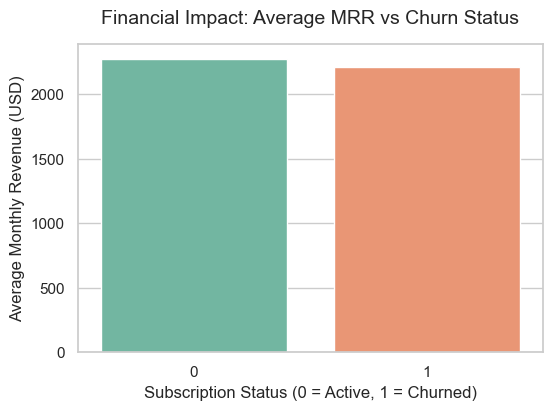

In [31]:
# Plot average Monthly Recurring Revenue (MRR) by subscription status
plt.figure(figsize=(6, 4))
sns.barplot(data=revenue_churn_analysis, x='has_churned', y='mrr_amount', palette='Set2', hue='has_churned', legend=False)

plt.title('Financial Impact: Average MRR vs Churn Status', fontsize=14, pad=15)
plt.xlabel('Subscription Status (0 = Active, 1 = Churned)', fontsize=12)
plt.ylabel('Average Monthly Revenue (USD)', fontsize=12)

plt.show()


## Phase 3: Data Preprocessing & Machine Learning
In this phase, we prepare our feature matrix by separating categorical variables, scaling relevant distributions, and splitting data into training and testing sets to train our Churn Prediction models.


In [32]:
# import machine learning tools
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
print("Tools loaded successfully")

Tools loaded successfully


In [33]:
# select predictive features and apply one hot encoding
features_to_use = ['plan_tier_x','seats_x','mrr_amount','is_trial_x',
                  'total_clicks','total_duration_seconds','total_errors',
                  'total_tickets','average_satisfaction']
X = master_df[features_to_use]
# convert categorical to 0 and 1
X = pd.get_dummies(X,columns = ['plan_tier_x'],drop_first=True)
y = master_df['has_churned']
X.head()

,seats_x,mrr_amount,is_trial_x,total_clicks,total_duration_seconds,total_errors,total_tickets,average_satisfaction,plan_tier_x_Enterprise,plan_tier_x_Pro
0,14,2786,False,63.0,26418.0,2.0,4.0,3.500000,True,False
1,17,833,False,36.0,6819.0,6.0,4.0,4.000000,False,True
2,17,833,False,36.0,6819.0,6.0,4.0,4.000000,False,True
3,62,0,True,25.0,13877.0,2.0,4.0,4.333333,True,False
4,62,0,True,25.0,13877.0,2.0,4.0,4.333333,True,False


In [34]:
#  Split the dataset into training and testing sets (80% train, 20% test)
X_train, X_test , y_train, y_test = train_test_split(X ,y, test_size = 0.2, random_state = 42, stratify = y)

print(f"Training set size: {X_train.shape[0]} rows")
print(f"Testing set size: {X_test.shape[0]} rows")

Training set size: 5943 rows
Testing set size: 1486 rows


In [35]:
# initializing Random Forest with 100 trees
model = RandomForestClassifier(n_estimators = 100, random_state = 42)
model.fit(X_train, y_train)

#predictions
predictions = model.predict(X_test)
print("Model training and predictions completed successfully")

Model training and predictions completed successfully


In [36]:
# Evaluate model performance
print("Classification Report: ")
print(classification_report(y_test, predictions))

# 0 means active clients , 1 Clients that churned
# recall = 0.99 , 99% of the clients that churned were predicted by this model

Classification Report: 
              precision    recall  f1-score   support

           0       0.83      0.28      0.42       294
           1       0.85      0.99      0.91      1192

    accuracy                           0.85      1486
   macro avg       0.84      0.63      0.66      1486
weighted avg       0.84      0.85      0.81      1486



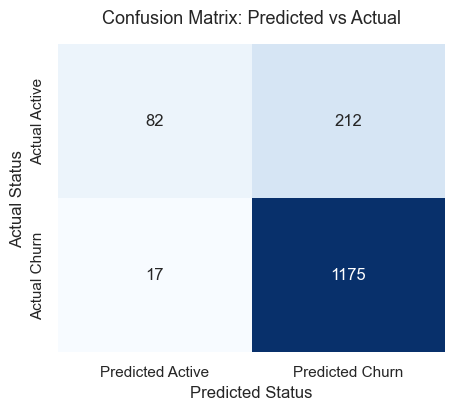

In [37]:
# Confusion Matrix for better visualization
cm = confusion_matrix(y_test, predictions)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted Active', 'Predicted Churn'],
            yticklabels=['Actual Active', 'Actual Churn'])

plt.title('Confusion Matrix: Predicted vs Actual', fontsize=13, pad=15)
plt.ylabel('Actual Status')
plt.xlabel('Predicted Status')
plt.savefig('confusion_matrix.png',bbox_inches = 'tight')
plt.show()

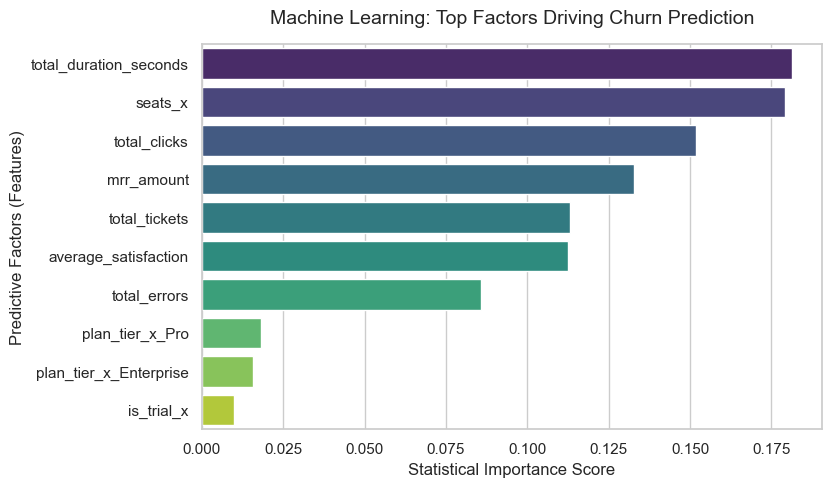

In [39]:
# What were the most important features in regards to churn?
importances = model.feature_importances_
feature_names = X.columns

# Create a dataframe for easy plotting:
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
importance_df = importance_df.sort_values(by = "Importance", ascending = False)

# Plot the features using Seaborn
plt.figure(figsize=(8, 5))
sns.barplot(data=importance_df, x='Importance', y='Feature', palette='viridis', hue='Feature', legend=False)

plt.title('Machine Learning: Top Factors Driving Churn Prediction', fontsize=14, pad=15)
plt.xlabel('Statistical Importance Score', fontsize=12)
plt.ylabel('Predictive Factors (Features)', fontsize=12)
plt.savefig('feature_importance.png',bbox_inches = 'tight')
plt.show()